In [2]:
# delete after finish
import sys
print(sys.executable)

c:\Users\flami\AppData\Local\Programs\Python\Python312\python.exe


# Start Project

In [3]:
import os
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# create sqlite db
root_folder = "."
conn = sqlite3.connect("mimic.db")

for root, dirs, files in os.walk(root_folder):
    for filename in files:
        if filename.endswith(".csv"):
            filepath = os.path.join(root, filename)

            # change file names to folder_name
            if root_folder == root:
                tablename = filename.replace(".csv", "")
            else:
                subfolder = os.path.basename(root)
                tablename = f"{subfolder}_{filename}".replace(".csv", "")

            # read to db
            df = pd.read_csv(filepath)
            df.to_sql(tablename, conn, if_exists="replace", index=False)

C:\Users\flami\AppData\Local\Temp\ipykernel_9680\2397065530.py:23: DtypeWarning: Columns (0: administration_type, 1: barcode_type, 2: reason_for_no_barcode, 3: complete_dose_not_given, 4: dose_due, 5: dose_due_unit, 6: dose_given, 7: dose_given_unit, 8: will_remainder_of_dose_be_given, 9: product_unit, 10: product_code, 11: product_description, 12: product_description_other, 13: infusion_rate_adjustment, 14: infusion_rate_unit, 15: route, 16: infusion_complete, 17: completion_interval, 18: new_iv_bag_hung, 19: continued_infusion_in_other_location, 20: restart_interval, 21: side, 22: site, 23: non_formulary_visual_verification) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


# Basic Information

In [4]:
# list tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
print(tables)

                       name
0           demo_subject_id
1               dur_by_type
2           hosp_admissions
3              hosp_d_hcpcs
4      hosp_d_icd_diagnoses
5     hosp_d_icd_procedures
6           hosp_d_labitems
7        hosp_diagnoses_icd
8             hosp_drgcodes
9          hosp_dur_by_type
10                hosp_emar
11         hosp_emar_detail
12         hosp_hcpcsevents
13           hosp_labevents
14  hosp_microbiologyevents
15                 hosp_omr
16            hosp_patients
17            hosp_pharmacy
18                 hosp_poe
19          hosp_poe_detail
20       hosp_prescriptions
21      hosp_procedures_icd
22            hosp_provider
23            hosp_services
24           hosp_transfers
25            icu_caregiver
26          icu_chartevents
27              icu_d_items
28       icu_datetimeevents
29             icu_icustays
30     icu_ingredientevents
31          icu_inputevents
32         icu_outputevents
33      icu_procedureevents


In [5]:
# get schema and preview a table

for table in ("hosp_patients", "hosp_admissions", "hosp_labevents", "icu_icustays"):

    schema = pd.read_sql(f"PRAGMA table_info({table})", conn)
    print(f"Schema for {table}:")
    print(schema)

    preview = pd.read_sql(f"SELECT * FROM {table} LIMIT 5", conn)
    print(f"Preview for {table}:")
    print(preview)
    print("\n")

Schema for hosp_patients:
   cid               name     type  notnull dflt_value  pk
0    0         subject_id  INTEGER        0       None   0
1    1             gender     TEXT        0       None   0
2    2         anchor_age  INTEGER        0       None   0
3    3        anchor_year  INTEGER        0       None   0
4    4  anchor_year_group     TEXT        0       None   0
5    5                dod     TEXT        0       None   0
Preview for hosp_patients:
   subject_id gender  anchor_age  anchor_year anchor_year_group         dod
0    10014729      F          21         2125       2011 - 2013         NaN
1    10003400      F          72         2134       2011 - 2013  2137-09-02
2    10002428      F          80         2155       2011 - 2013         NaN
3    10032725      F          38         2143       2011 - 2013  2143-03-30
4    10027445      F          48         2142       2011 - 2013  2146-02-09


Schema for hosp_admissions:
    cid                  name     type  notnull 

In [6]:
# missing values check
for table in ("hosp_patients", "hosp_admissions", "hosp_labevents", "icu_icustays"):
    df = pd.read_sql(f"SELECT * FROM {table}", conn)
    print(f"{table} Missing Values:")
    print(df.isnull().sum())

hosp_patients Missing Values:
subject_id            0
gender                0
anchor_age            0
anchor_year           0
anchor_year_group     0
dod                  69
dtype: int64
hosp_admissions Missing Values:
subject_id                0
hadm_id                   0
admittime                 0
dischtime                 0
deathtime               260
admission_type            0
admit_provider_id         0
admission_location        0
discharge_location       42
insurance                 0
language                  0
marital_status           12
race                      0
edregtime                93
edouttime                93
hospital_expire_flag      0
dtype: int64
hosp_labevents Missing Values:
labevent_id              0
subject_id               0
hadm_id              28420
specimen_id              0
itemid                   0
order_provider_id    90897
charttime                0
storetime              992
value                 9588
valuenum             12481
valueuom           

In [7]:
for table in ("hosp_patients", "hosp_admissions", "hosp_labevents", "icu_icustays"):
    df = pd.read_sql(f"SELECT COUNT(DISTINCT subject_id) AS dist FROM {table}", conn)
    print(f"{table} DISTINCT Values:")
    print(df)

hosp_patients DISTINCT Values:
   dist
0   100
hosp_admissions DISTINCT Values:
   dist
0   100
hosp_labevents DISTINCT Values:
   dist
0   100
icu_icustays DISTINCT Values:
   dist
0   100


# Hospital Patient Analysis

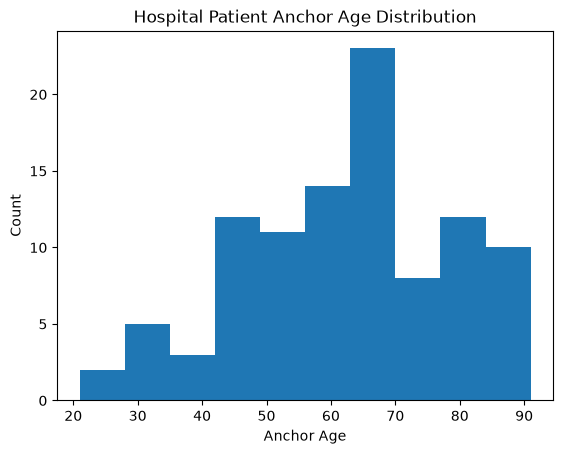

In [8]:
# age distribution for hosp patients
hosp_pat_ages = pd.read_sql("""
SELECT anchor_age, COUNT(*) as n FROM hosp_patients
GROUP BY anchor_age
ORDER BY anchor_age
""", conn)

# plot ages
plt.hist(hosp_pat_ages["anchor_age"], weights=hosp_pat_ages["n"])
plt.title("Hospital Patient Anchor Age Distribution")
plt.xlabel("Anchor Age")
plt.ylabel("Count")
plt.show()

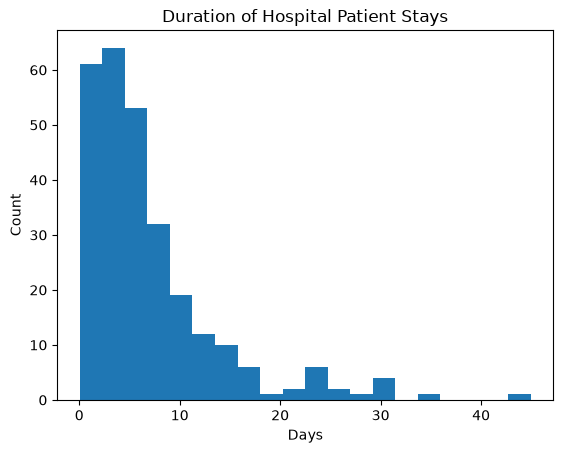

In [9]:
# duration of stay
hosp_durations = pd.read_sql("""
    SELECT admission_type, (julianday(dischtime) - julianday(admittime)) AS stay_duration
    FROM hosp_admissions
""", conn)

# plot duration of stay
plt.hist(hosp_durations["stay_duration"], bins=20)
plt.title("Duration of Hospital Patient Stays")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()

In [10]:
# dist of admission types
admissions = pd.read_sql("SELECT admission_type, COUNT(*) AS n FROM hosp_admissions GROUP BY admission_type", conn)
print(admissions)

                admission_type    n
0       AMBULATORY OBSERVATION    5
1                 DIRECT EMER.   15
2           DIRECT OBSERVATION    7
3                     ELECTIVE   13
4               EU OBSERVATION   30
5                     EW EMER.  104
6            OBSERVATION ADMIT   45
7  SURGICAL SAME DAY ADMISSION   18
8                       URGENT   38


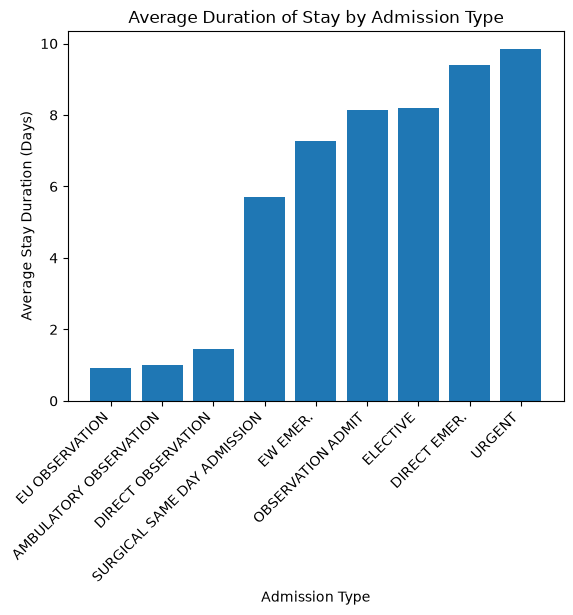

In [11]:
# remove table for tests
conn.execute("DROP TABLE IF EXISTS hosp_dur_by_type")

# compare avg stay times for each type of admission
conn.execute("""CREATE TABLE IF NOT EXISTS hosp_dur_by_type AS
             SELECT admission_type, AVG(stay_duration) as avg
             FROM (SELECT admission_type, (julianday(dischtime) - julianday(admittime)) AS stay_duration FROM hosp_admissions)
             GROUP BY admission_type
             """)

hosp_duration_by_type = pd.read_sql("SELECT * FROM hosp_dur_by_type ORDER BY avg ASC", conn)

# plot duration by admission type
plt.bar(hosp_duration_by_type["admission_type"], hosp_duration_by_type["avg"])
plt.title("Average Duration of Stay by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Average Stay Duration (Days)")
plt.xticks(rotation=45, ha="right")
plt.show()

# ICU Patient Analysis

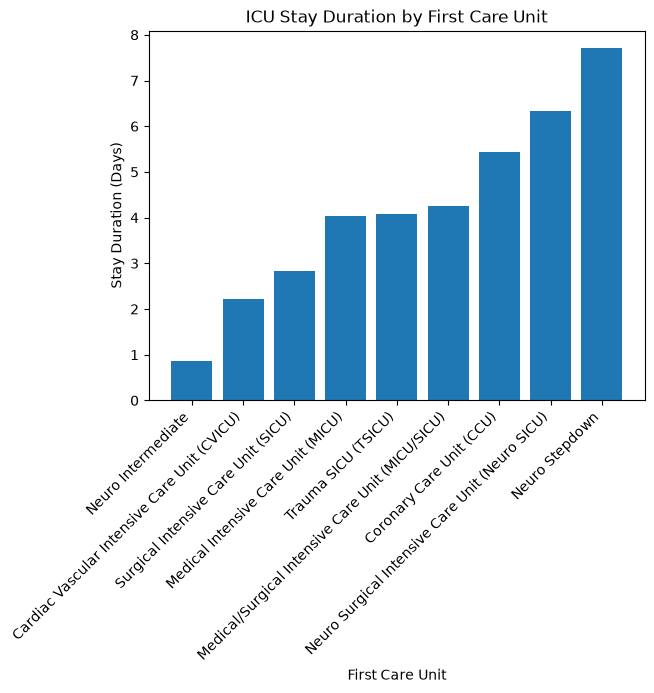

In [12]:
# ICU stay duration distribution by first care unit
ICU_stay_duration_by_FCU = pd.read_sql("""
    SELECT first_careunit, AVG(stay_duration) AS avg_duration
    FROM (SELECT first_careunit, (julianday(outtime)-julianday(intime)) AS stay_duration FROM icu_icustays)
    GROUP BY first_careunit
    ORDER BY avg_duration
    """, conn)

plt.bar(ICU_stay_duration_by_FCU["first_careunit"], ICU_stay_duration_by_FCU["avg_duration"])
plt.title("ICU Stay Duration by First Care Unit")
plt.xlabel("First Care Unit")
plt.ylabel("Stay Duration (Days)")
plt.xticks(rotation=45, ha="right")
plt.show()

# Combined EDA

In [13]:
# combine hosp variables
combined = pd.read_sql("""
    SELECT a.subject_id, (julianday(a.dischtime) - julianday(a.admittime)) AS stay_duration, a.marital_status, a.race, p.anchor_age, p.gender
    FROM hosp_patients AS p
    JOIN hosp_admissions a on p.subject_id = a.subject_id
""", conn)
# 2 cont 3 discrete

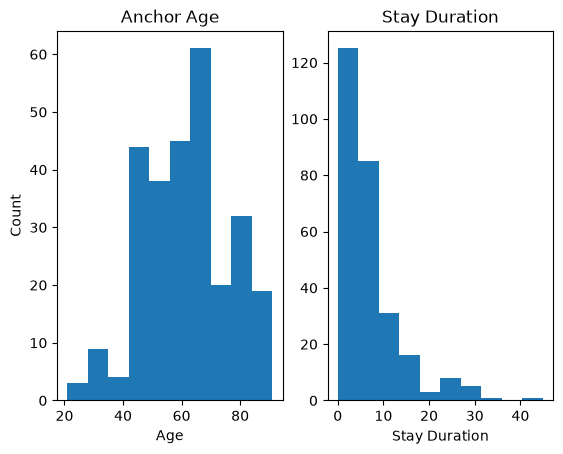

In [14]:
# Continuous var distributions
fig, axs = plt.subplots(1, 2)

# anchor age
axs[0].hist(combined["anchor_age"])
axs[0].set_title("Anchor Age")
axs[0].set_xlabel("Age")
axs[0].set_ylabel("Count")

# stay duration
axs[1].hist(combined["stay_duration"])
axs[1].set_title("Stay Duration")
axs[1].set_xlabel("Stay Duration")

plt.show()

Text(0.5, 0, 'Gender')

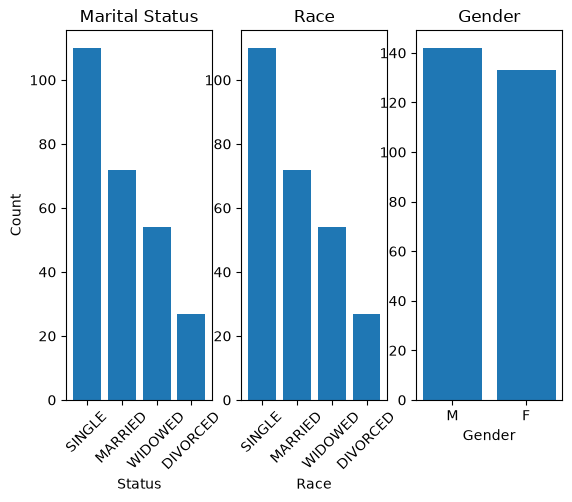

In [22]:
# Discrete var distributions
fig, axs = plt.subplots(1, 3)

# marital status
marital_status = combined["marital_status"].value_counts()
axs[0].bar(marital_status.index, marital_status.values)
axs[0].set_title("Marital Status")
axs[0].set_xlabel("Status")
axs[0].set_ylabel("Count")
axs[0].tick_params(axis="x", labelrotation=45)

# race
race = combined["race"].value_counts()
axs[1].bar(marital_status.index, marital_status.values)
axs[1].set_title("Race")
axs[1].set_xlabel("Race")
axs[1].tick_params(axis="x", labelrotation=45)

#gender
gender = combined["gender"].value_counts()
axs[2].bar(gender.index, gender.values)
axs[2].set_title("Gender")
axs[2].set_xlabel("Gender")